In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1 ODE and Exact solution
def f(t, y):
    return y - (0.5*np.exp(0.5*t)*np.sin(5*t)) + 5*(np.exp(0.5*t)*np.cos(5*t))

def exact(t):
    return np.exp(0.5*t)*np.sin(5*t)

In [3]:
# 2 Numerical methods

def euler(f, t0, T, y0, nt):
    h = (T-t0)/nt
    t = np.linspace(t0, T, nt+1)
    y = np.zeros(nt+1)
    y[0] = y0

    for n in range(nt):
        y[n+1] = y[n] + h*f(t[n], y[n])
        
    return t, y, h


def leapfrog(f, t0, T, y0, nt):
    h = (T - t0) / nt
    t = np.linspace(t0, T, nt + 1)
    y = np.zeros(nt + 1)
    y[0] = y0

    y[1] = y[0] + h * f(t[0], y[0])

    for n in range(1, nt):
        y[n+1] = y[n-1] + 2*h*f(t[n], y[n])

    return t, y, h


def AB2(f, t0, T, y0, nt):
    h = (T - t0) / nt
    t = np.linspace(t0, T, nt + 1)
    y = np.zeros(nt + 1)
    y[0] = y0

    y[1] = y[0] + h * f(t[0], y[0])

    for n in range(1, nt):
        fn   = f(t[n], y[n])
        fnm1 = f(t[n-1], y[n-1])
        y[n+1] = y[n] + h * (3*fn - fnm1) / 2

    return t, y, h


def AB3(f, t0, T, y0, nt):
    h = (T - t0) / nt
    t = np.linspace(t0, T, nt + 1)
    y = np.zeros(nt + 1)
    y[0] = y0

    # first two starting values by Euler method
    y[1] = y[0] + h * f(t[0], y[0])
    y[2] = y[1] + h * f(t[1], y[1])
    
    for n in range(2, nt):
        f1   = f(t[n], y[n])
        f2 = f(t[n-1], y[n-1])
        f3 = f(t[n-2], y[n-2])
        y[n+1] = y[n] + h * (23*f1 - 16*f2 + 5*f3) / 12
    return t, y, h
    

In [4]:
# 3 Error analysis

def run_method(method, method_name, f, exact, t0, T, y0, nt_list):
    results = []
    prev_h = None
    prev_max_err = None
    
    for nt in nt_list:
        t, y, h = method(f, t0, T, y0, nt)
        y_ex = exact(t)
        err = np.abs(y - y_ex)
        
        final_err = err[-1]
        max_err = np.max(err)
        
        if prev_max_err is None:
            order = np.nan
        else:
            order = np.log(prev_max_err/max_err) / np.log(prev_h/h)
        
        results.append({
            "method": method_name,
            "nt": nt,
            "h": h,
            "t": t,
            "y": y,
            "y_ex": y_ex,
            "err": err,
            "final_err": final_err,
            "max_err": max_err,
            "order": order
        })

        prev_h = h
        prev_max_err = max_err

    return results

In [ ]:
# 4. print results (by gpt)
def print_results(results):
    print(f"\nMethod: {results[0]['method']}")
    print("-" * 70)
    print(f"{'nt':>6} {'h':>12} {'final_err':>15} {'max_err':>15} {'order':>10}")
    print("-" * 70)

    for r in results:
        if np.isnan(r["order"]):
            order_str = "   -   "
        else:
            order_str = f"{r['order']:.4f}"

        print(f"{r['nt']:6d} {r['h']:12.6f} {r['final_err']:15.6e} {r['max_err']:15.6e} {order_str:>10}")

In [10]:
def plot_all_solutions(results):
    method_name = results[0]["method"]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, r in zip(axes, results):
        ax.plot(r["t"], r["y_ex"], label="Exact")
        ax.plot(r["t"], r["y"], "--", label="Numerical")
        ax.set_title(f'nt = {r["nt"]}, h = {r["h"]:.4f}')
        ax.set_xlabel("t")
        ax.set_ylabel("y")
        ax.grid(True)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)
    fig.suptitle(f"{method_name}: numerical solution vs exact solution", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

In [11]:
def plot_error_comparison(all_results, err_type="max_err"):
    plt.figure(figsize=(8, 6))

    # 실제 error 곡선
    for results in all_results:
        h_vals = np.array([r["h"] for r in results], dtype=float)
        err_vals = np.array([r[err_type] for r in results], dtype=float)

        idx = np.argsort(h_vals)
        h_vals = h_vals[idx]
        err_vals = err_vals[idx]

        plt.loglog(h_vals, err_vals, "o-", label=results[0]["method"])

    # reference slope lines
    h_ref = np.array(sorted([r["h"] for r in all_results[0]]), dtype=float)

    # 가장 작은 h에서 적당히 맞춰서 reference line 생성
    euler_last = all_results[0][-1][err_type]
    leap_last  = all_results[1][-1][err_type]
    ab3_last   = all_results[3][-1][err_type]

    ref1 = euler_last * (h_ref / h_ref[0])**1
    ref2 = leap_last  * (h_ref / h_ref[0])**2
    ref3 = ab3_last   * (h_ref / h_ref[0])**3

    plt.loglog(h_ref, ref1, "--", label=r"$O(h)$")
    plt.loglog(h_ref, ref2, "--", label=r"$O(h^2)$")
    plt.loglog(h_ref, ref3, "--", label=r"$O(h^3)$")

    plt.xlabel("h")
    plt.ylabel(err_type)
    plt.title(f"{err_type} vs h (log-log scale)")
    plt.grid(True, which="both")
    plt.legend()
    plt.show()

In [12]:
def fitted_order(results, err_type="max_err", last_n=3):
    h_vals = np.array([r["h"] for r in results], dtype=float)
    err_vals = np.array([r[err_type] for r in results], dtype=float)

    idx = np.argsort(h_vals)
    h_vals = h_vals[idx]
    err_vals = err_vals[idx]

    h_fit = h_vals[:last_n]
    e_fit = err_vals[:last_n]

    p = np.polyfit(np.log(h_fit), np.log(e_fit), 1)
    return p[0]

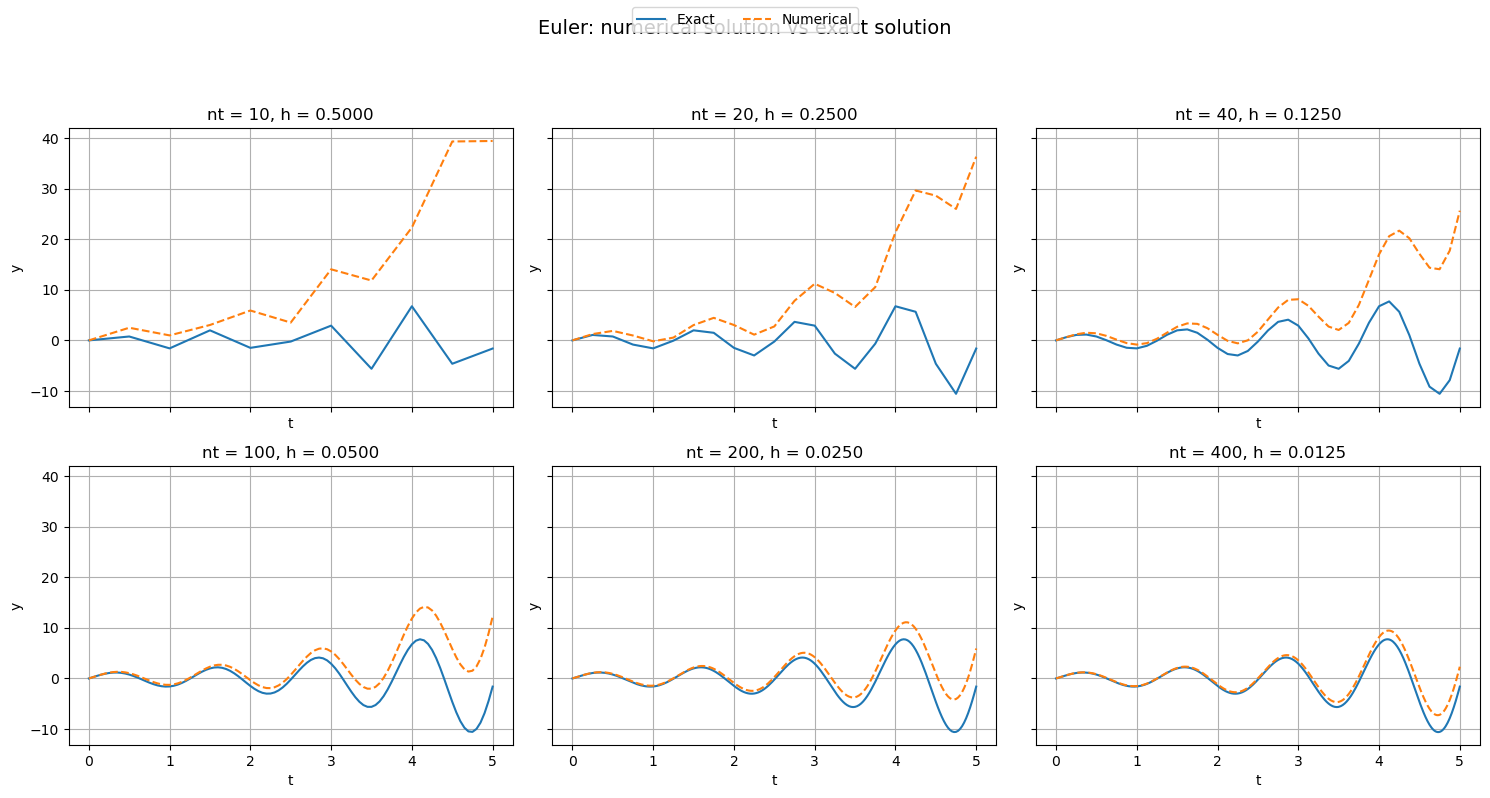

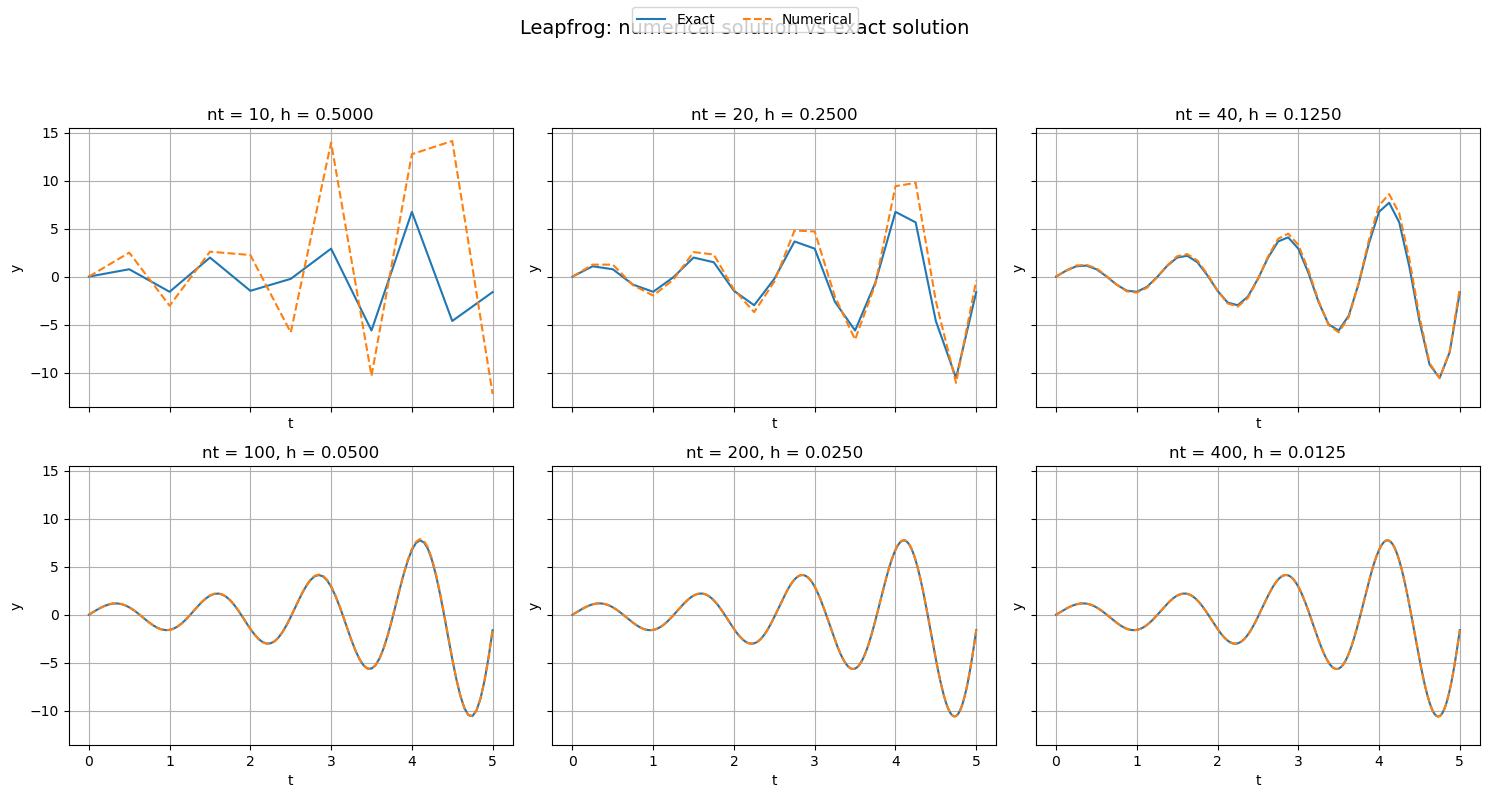

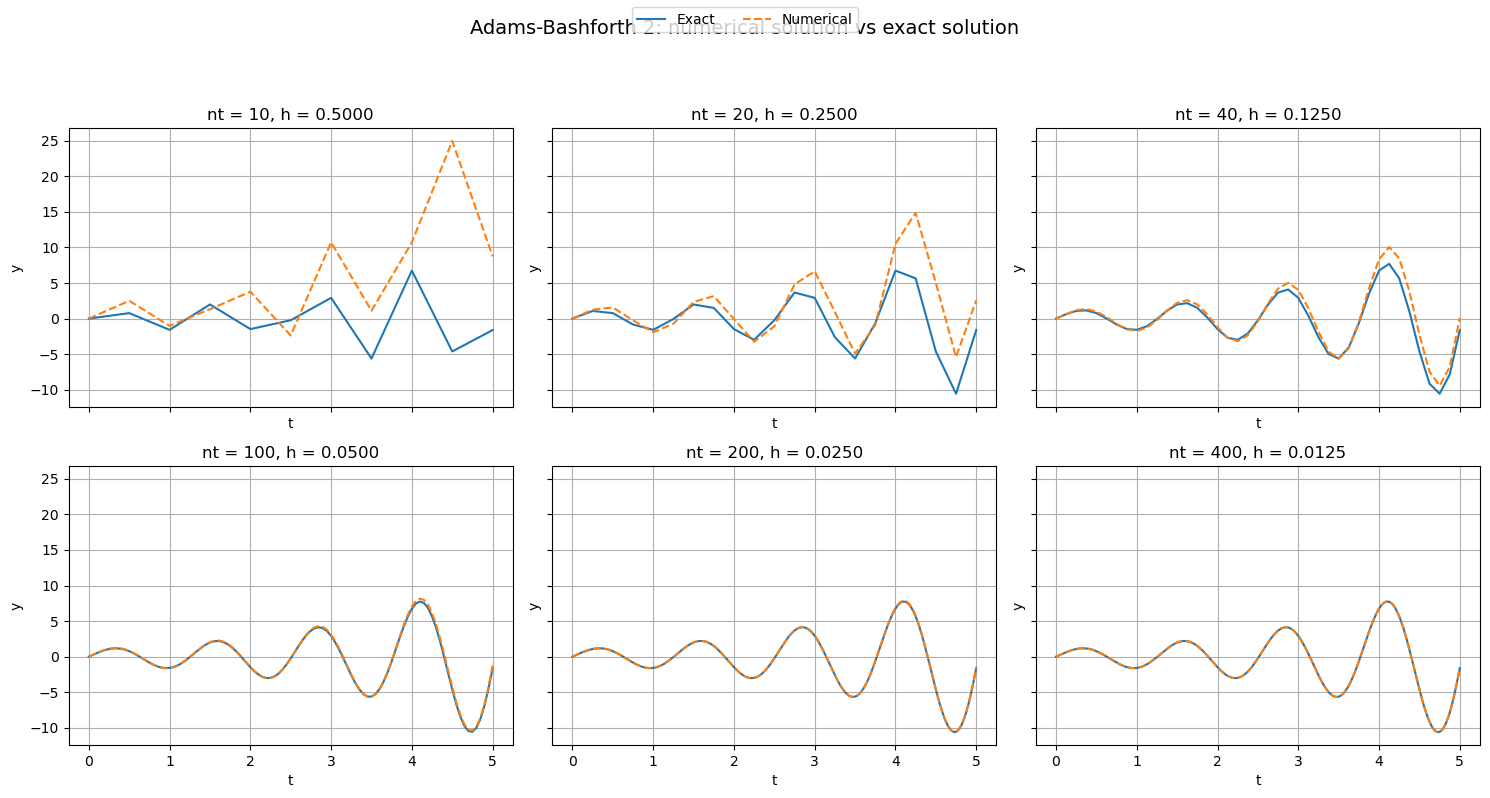

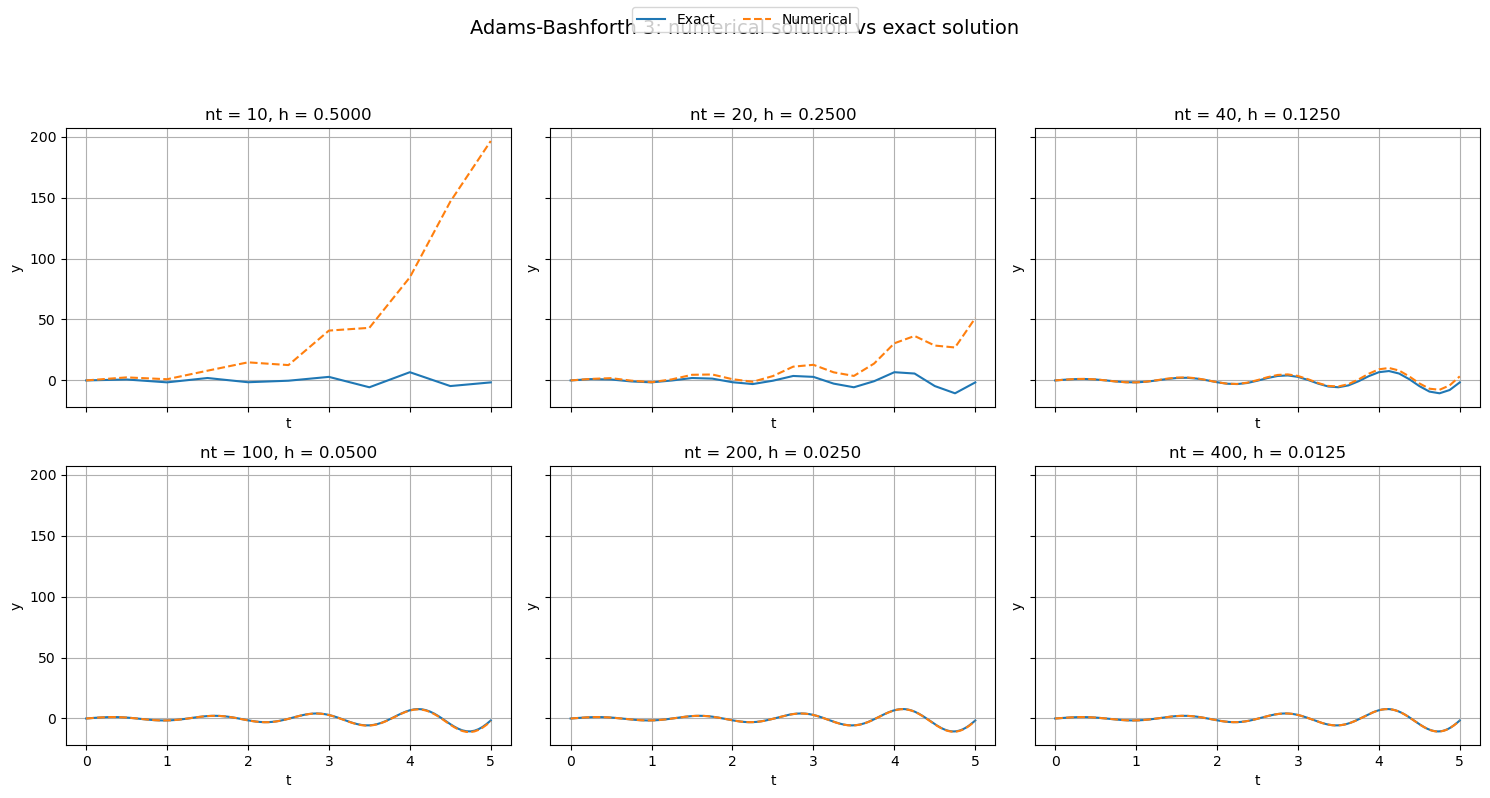

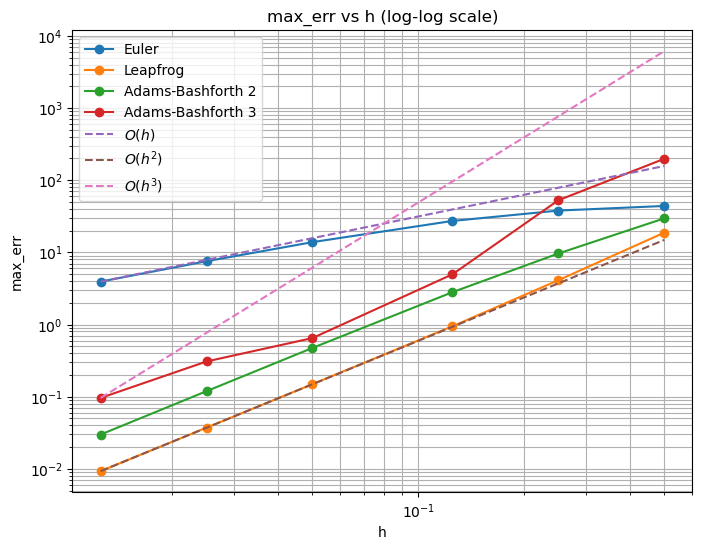

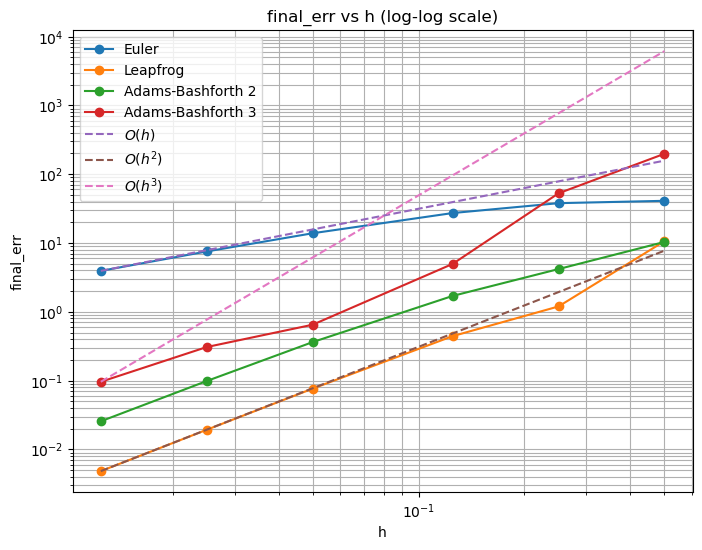

Euler fitted order = 0.9084044988113725
Leapfrog fitted order = 2.0019695590666564
AB2 fitted order = 1.993653057718064
AB3 fitted order = 1.3777919221673067


In [13]:
t0 = 0.0
T = 5.0
y0 = 0.0
nt_list = [10, 20, 40, 100, 200, 400]

euler_results = run_method(euler, "Euler", f, exact, t0, T, y0, nt_list)
leapfrog_results = run_method(leapfrog, "Leapfrog", f, exact, t0, T, y0, nt_list)
ab2_results = run_method(AB2, "Adams-Bashforth 2", f, exact, t0, T, y0, nt_list)
ab3_results = run_method(AB3, "Adams-Bashforth 3", f, exact, t0, T, y0, nt_list)

plot_all_solutions(euler_results)
plot_all_solutions(leapfrog_results)
plot_all_solutions(ab2_results)
plot_all_solutions(ab3_results)


# error comparison plot
plot_error_comparison(
    [euler_results, leapfrog_results, ab2_results, ab3_results],
    err_type="max_err"
)

plot_error_comparison(
    [euler_results, leapfrog_results, ab2_results, ab3_results],
    err_type="final_err"
)

print("Euler fitted order =", fitted_order(euler_results, "max_err", last_n=3))
print("Leapfrog fitted order =", fitted_order(leapfrog_results, "max_err", last_n=3))
print("AB2 fitted order =", fitted_order(ab2_results, "max_err", last_n=3))
print("AB3 fitted order =", fitted_order(ab3_results, "max_err", last_n=3))